# Stage 2 Analysis Dashboard

This notebook loads saved Stage 2 experiment outputs and provides a standardized analysis
layer for method comparison, support-size comparison, inner-step comparison,
repeated-episode stability inspection, prediction distribution diagnostics,
and thesis-ready result tables.

All plots use the shared DTU-aligned plotting utilities from `master_thesis.plotting`.
This notebook does not re-run any experiments; it analyzes saved outputs only.


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from master_thesis.plotting import (
    set_thesis_style,
    plot_stage2_metric_comparison,
    plot_repeated_episode_boxplot,
    plot_inner_step_curve,
    plot_prediction_probability_distribution,
    plot_support_size_curve,
)

set_thesis_style(palette="dtu", font_scale=1.05, grid=False)

EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
SUMMARY_PATH = EXPERIMENT_ROOT / "experiment_summary.csv"
REPORTS_DIR = PROJECT_ROOT / "reports" / "stage2"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


## Load Experiment Registry


In [2]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Experiment summary not found: {SUMMARY_PATH}")

summary_df = pd.read_csv(SUMMARY_PATH)
print("Loaded experiment summary:", SUMMARY_PATH)
print("Rows:", len(summary_df))
print("Methods:", summary_df["method"].unique().tolist() if "method" in summary_df.columns else "N/A")
display(summary_df.head(20))


Loaded experiment summary: /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Rows: 8
Methods: ['anil', 'finetune', 'fomaml', 'maml']


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,n_metric_rows,n_predictions,...,recall_at_10_mean,recall_at_10_std,ndcg_at_10_mean,ndcg_at_10_std,precision_at_20_mean,precision_at_20_std,recall_at_20_mean,recall_at_20_std,ndcg_at_20_mean,ndcg_at_20_std
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,success,20,205,...,0.906623,0.126552,0.898369,0.087197,0.744766,0.130334,1.0,0.0,0.950785,0.036881
1,stage2__init-A_weak_only__method-anil__kpos-5_...,anil,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,success,20,205,...,0.912835,0.127617,0.849515,0.076135,0.744766,0.130334,1.0,0.0,0.891858,0.061573
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,5,5,5,no_target_episodes_available,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,success,20,205,...,0.920909,0.119990,0.896894,0.072946,0.744766,0.130334,1.0,0.0,0.941844,0.059382
5,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,5,success,20,205,...,0.931169,0.112947,0.866941,0.123312,0.744766,0.130334,1.0,0.0,0.912426,0.105749
7,stage2__init-A_weak_only__method-maml__kpos-5_...,maml,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dashboard Filters

Edit the variables below to filter the experiments shown in all subsequent cells.
Set any filter to `None` to include all values.


In [3]:
SELECTED_TARGET_DEPARTMENT = "Logistics"
METHOD_FILTER = None              # e.g. ["anil", "finetune"]
INIT_FILTER = None                # e.g. ["A_weak_only"]
SUPPORT_FILTER = None             # e.g. (2, 2) for n_support_pos=2, n_support_neg=2
INNER_STEPS_FILTER = None         # e.g. [3, 5]
SELECTED_EXPERIMENT_ID = None     # e.g. "stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-3__target-Logistics"


In [4]:
filtered_df = summary_df.copy()

if "target_department" in filtered_df.columns and SELECTED_TARGET_DEPARTMENT is not None:
    filtered_df = filtered_df[filtered_df["target_department"] == SELECTED_TARGET_DEPARTMENT].copy()
if METHOD_FILTER is not None and "method" in filtered_df.columns:
    filtered_df = filtered_df[filtered_df["method"].isin(METHOD_FILTER)].copy()
if INIT_FILTER is not None and "init_name" in filtered_df.columns:
    filtered_df = filtered_df[filtered_df["init_name"].isin(INIT_FILTER)].copy()
if SUPPORT_FILTER is not None and {"n_support_pos", "n_support_neg"}.issubset(filtered_df.columns):
    filtered_df = filtered_df[
        (filtered_df["n_support_pos"] == SUPPORT_FILTER[0]) &
        (filtered_df["n_support_neg"] == SUPPORT_FILTER[1])
    ].copy()
if INNER_STEPS_FILTER is not None and "inner_steps" in filtered_df.columns:
    filtered_df = filtered_df[filtered_df["inner_steps"].isin(INNER_STEPS_FILTER)].copy()

print("Filtered rows:", len(filtered_df))
display(filtered_df.head(20))


Filtered rows: 8


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,n_metric_rows,n_predictions,...,recall_at_10_mean,recall_at_10_std,ndcg_at_10_mean,ndcg_at_10_std,precision_at_20_mean,precision_at_20_std,recall_at_20_mean,recall_at_20_std,ndcg_at_20_mean,ndcg_at_20_std
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,success,20,205,...,0.906623,0.126552,0.898369,0.087197,0.744766,0.130334,1.0,0.0,0.950785,0.036881
1,stage2__init-A_weak_only__method-anil__kpos-5_...,anil,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,success,20,205,...,0.912835,0.127617,0.849515,0.076135,0.744766,0.130334,1.0,0.0,0.891858,0.061573
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,5,5,5,no_target_episodes_available,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,success,20,205,...,0.920909,0.119990,0.896894,0.072946,0.744766,0.130334,1.0,0.0,0.941844,0.059382
5,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,5,success,20,205,...,0.931169,0.112947,0.866941,0.123312,0.744766,0.130334,1.0,0.0,0.912426,0.105749
7,stage2__init-A_weak_only__method-maml__kpos-5_...,maml,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Method Comparison


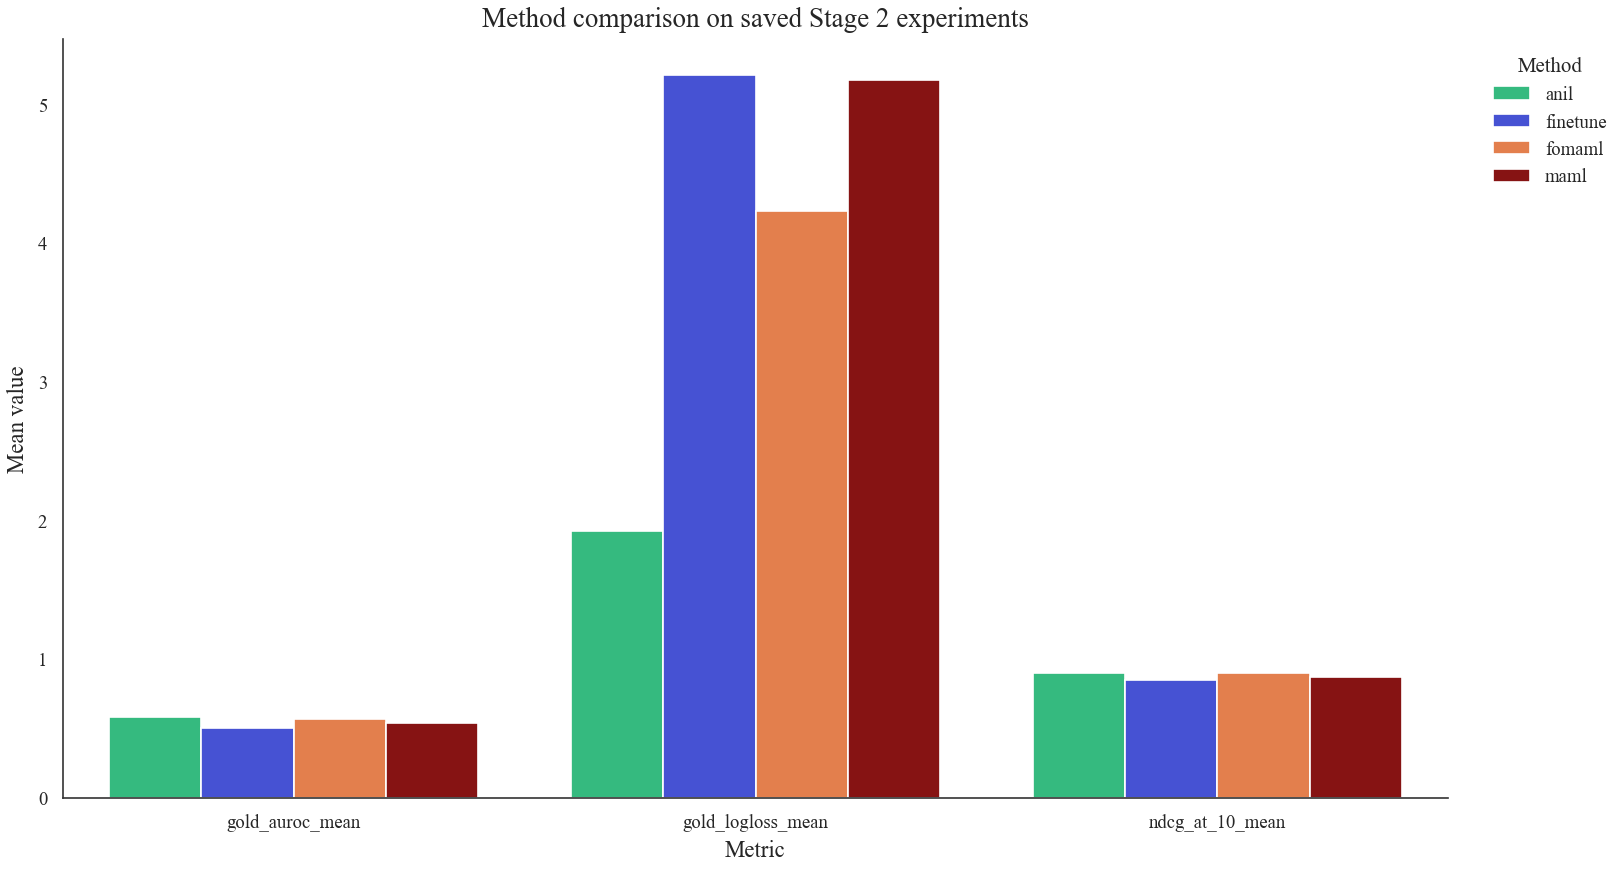

In [5]:
metric_columns = [
    c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in filtered_df.columns
]
if not filtered_df.empty and metric_columns and "method" in filtered_df.columns:
    fig, ax = plot_stage2_metric_comparison(
        filtered_df,
        metrics=metric_columns,
        group_col="method",
        title="Method comparison on saved Stage 2 experiments",
    )
else:
    print("Method comparison plot could not be produced from the current filtered registry.")


## Support-Size Comparison


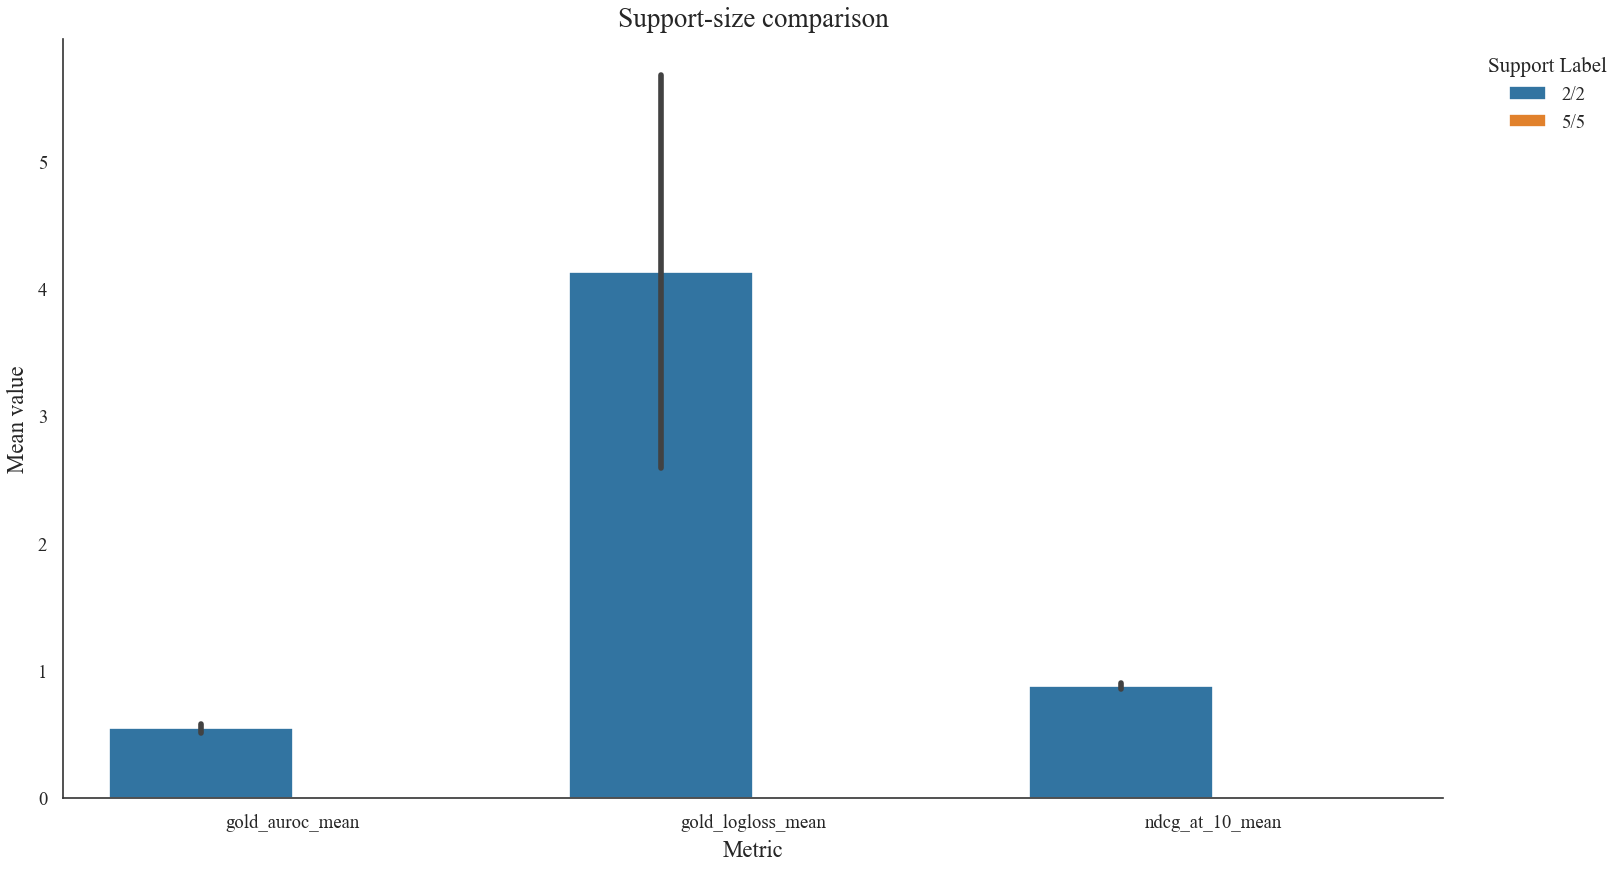

In [6]:
if not filtered_df.empty and {"n_support_pos", "n_support_neg"}.issubset(filtered_df.columns):
    support_df = filtered_df.copy()
    support_df["support_label"] = (
        support_df["n_support_pos"].astype(str) + "/" + support_df["n_support_neg"].astype(str)
    )
    metric_columns_s = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in support_df.columns
    ]
    if metric_columns_s and len(support_df["support_label"].unique()) > 1:
        fig, ax = plot_stage2_metric_comparison(
            support_df,
            metrics=metric_columns_s,
            group_col="support_label",
            title="Support-size comparison",
        )
    else:
        print("Support-size comparison skipped: fewer than 2 distinct support configurations.")


## Inner-Step Adaptation Curve


In [7]:
if not filtered_df.empty and "inner_steps" in filtered_df.columns:
    _has_method = "method" in filtered_df.columns
    _step_values = filtered_df["inner_steps"].unique()
    for _metric_col in [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in filtered_df.columns
    ]:
        if len(_step_values) > 1:
            _kwargs = dict(
                metric_col=_metric_col,
                step_col="inner_steps",
                title=f"{_metric_col} by inner-loop steps",
            )
            if _has_method:
                _kwargs["method_col"] = "method"
            fig, ax = plot_inner_step_curve(filtered_df, **_kwargs)
        else:
            print(f"Inner-step curve skipped for {_metric_col}: only one inner_steps value.")


Inner-step curve skipped for gold_auroc_mean: only one inner_steps value.
Inner-step curve skipped for gold_logloss_mean: only one inner_steps value.
Inner-step curve skipped for ndcg_at_10_mean: only one inner_steps value.


## Initialization Ablation


In [8]:
if not filtered_df.empty and "init_name" in filtered_df.columns:
    metric_columns_i = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in filtered_df.columns
    ]
    if metric_columns_i and len(filtered_df["init_name"].unique()) > 1:
        fig, ax = plot_stage2_metric_comparison(
            filtered_df,
            metrics=metric_columns_i,
            group_col="init_name",
            title="Initialization ablation",
        )
    else:
        print("Initialization ablation skipped: fewer than 2 distinct init_name values.")


Initialization ablation skipped: fewer than 2 distinct init_name values.


## Per-Experiment Artifact Inspection

Set `SELECTED_EXPERIMENT_ID` in the filters cell to load and inspect a specific experiment's artifacts.


In [9]:
def load_experiment_artifacts(experiment_id: str) -> dict:
    exp_dir = EXPERIMENT_ROOT / experiment_id
    artifacts = {
        "metrics": pd.DataFrame(),
        "predictions": pd.DataFrame(),
        "history": pd.DataFrame(),
    }
    for key, filename in [("metrics", "metrics.csv"), ("predictions", "predictions.csv"), ("history", "history.csv")]:
        path = exp_dir / filename
        if path.exists():
            artifacts[key] = pd.read_csv(path)
    return artifacts


if SELECTED_EXPERIMENT_ID is not None:
    artifacts = load_experiment_artifacts(SELECTED_EXPERIMENT_ID)
    metrics_df = artifacts["metrics"]
    preds_df = artifacts["predictions"]
    history_df = artifacts["history"]

    print("metrics.csv rows:", len(metrics_df))
    display(metrics_df.head() if not metrics_df.empty else metrics_df)
    print("predictions.csv rows:", len(preds_df))
    display(preds_df.head() if not preds_df.empty else preds_df)
    print("history.csv rows:", len(history_df))
    display(history_df.head() if not history_df.empty else history_df)

    # Repeated-episode stability: one plot per metric
    if not metrics_df.empty:
        metric_candidates = [c for c in ["gold_auroc", "gold_logloss", "ndcg_at_10"] if c in metrics_df.columns]
        for _m in metric_candidates:
            fig, ax = plot_repeated_episode_boxplot(
                metrics_df,
                metric_col=_m,
                title=f"Repeated-episode stability ({_m}): {SELECTED_EXPERIMENT_ID}",
            )

    # Prediction probability distribution
    if not preds_df.empty:
        prob_cols = [c for c in ["y_prob", "pred_prob", "probability", "y_pred_prob"] if c in preds_df.columns]
        if prob_cols:
            fig, ax = plot_prediction_probability_distribution(
                preds_df,
                prob_col=prob_cols[0],
                method_col=None,  # single-experiment view
                title=f"Prediction distribution: {SELECTED_EXPERIMENT_ID}",
            )
else:
    print("Set SELECTED_EXPERIMENT_ID in the filters cell to inspect a saved experiment in detail.")


Set SELECTED_EXPERIMENT_ID in the filters cell to inspect a saved experiment in detail.


---
## Thesis-Ready Result Tables

The tables below are formatted for direct use as the basis for thesis tables.
Tables are also saved as CSV files in `reports/stage2/`.

| Table | Purpose |
|-------|---|
| D | Main Stage 2 benchmark: method × init × support × inner_steps |
| E | Adaptation dynamics: grouped by inner_steps |
| F | Support-size sensitivity: grouped by n_support_pos/n_support_neg |
| G | Initialization ablation: grouped by init_name |
| H | Best-run leaderboard: one row per experiment, sorted by primary metric |
| I | Stage 1 vs Stage 2 comparison for the target department |


In [10]:
# Helper: canonical metric column display names
_METRIC_RENAME = {
    "gold_auroc_mean": "AUROC mean",
    "gold_auroc_std": "AUROC std",
    "gold_logloss_mean": "Log-Loss mean",
    "gold_logloss_std": "Log-Loss std",
    "ndcg_at_10_mean": "NDCG@10 mean",
    "ndcg_at_10_std": "NDCG@10 std",
    "gold_ece_mean": "ECE mean",
    "gold_ece_std": "ECE std",
    "precision_at_10_mean": "P@10 mean",
    "precision_at_10_std": "P@10 std",
}

_MEAN_COLS = ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean", "gold_ece_mean", "precision_at_10_mean"]
_STD_COLS = ["gold_auroc_std", "gold_logloss_std", "ndcg_at_10_std", "gold_ece_std", "precision_at_10_std"]

def _available(cols, df):
    return [c for c in cols if c in df.columns]

def _format_table(df, rename=True):
    df = df.copy()
    if rename:
        df = df.rename(columns={k: v for k, v in _METRIC_RENAME.items() if k in df.columns})
    for c in df.select_dtypes(include="float").columns:
        df[c] = df[c].round(4)
    return df.reset_index(drop=True)


### Table D: Main Stage 2 Benchmark

Primary comparison of all methods. Rows correspond to unique (method, init_name, support, inner_steps) combinations.


In [11]:
_id_cols_d = [c for c in ["method", "init_name", "n_support_pos", "n_support_neg", "inner_steps",
                             "target_department", "status", "n_metric_rows"] if c in summary_df.columns]
_metric_cols_d = _available(_MEAN_COLS + _STD_COLS, summary_df)
_cols_d = _id_cols_d + _metric_cols_d

_sort_d = [c for c in ["method", "init_name", "n_support_pos", "inner_steps"] if c in _cols_d]

table_d = summary_df[_cols_d].sort_values(_sort_d).reset_index(drop=True)
table_d_display = _format_table(table_d)
display(table_d_display)

table_d.to_csv(REPORTS_DIR / "table_D_stage2_main_benchmark.csv", index=False)
print("Saved:", REPORTS_DIR / "table_D_stage2_main_benchmark.csv")


,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,n_metric_rows,AUROC mean,Log-Loss mean,NDCG@10 mean,ECE mean,P@10 mean,AUROC std,Log-Loss std,NDCG@10 std,ECE std,P@10 std
0,anil,A_weak_only,2,2,5,Logistics,success,20,0.5827,1.9245,0.8984,0.4181,0.7277,0.2008,1.8477,0.0872,0.2138,0.1310
1,anil,A_weak_only,5,5,5,Logistics,success,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,finetune,A_weak_only,2,2,5,Logistics,success,20,0.5000,5.2049,0.8495,0.2826,0.7377,0.0000,3.1701,0.0761,0.1721,0.1597
3,finetune,A_weak_only,5,5,5,Logistics,no_target_episodes_available,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fomaml,A_weak_only,2,2,5,Logistics,success,20,0.5638,4.2263,0.8969,0.5455,0.7377,0.2261,3.6648,0.0729,0.2683,0.1205
5,fomaml,A_weak_only,5,5,5,Logistics,success,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,maml,A_weak_only,2,2,5,Logistics,success,20,0.5357,5.1728,0.8669,0.4711,0.7527,0.2072,5.9101,0.1233,0.2821,0.1538
7,maml,A_weak_only,5,5,5,Logistics,success,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_D_stage2_main_benchmark.csv


### Table E: Adaptation Dynamics by Inner Steps

Group by inner_steps to show how adaptation depth affects performance.


In [12]:
if "inner_steps" in summary_df.columns:
    _agg_e = {c: ["mean", "std"] for c in _available(_MEAN_COLS, summary_df)}
    if _agg_e:
        _group_e = [c for c in ["inner_steps", "method"] if c in summary_df.columns]
        table_e = summary_df.groupby(_group_e)[_available(_MEAN_COLS, summary_df)].agg(["mean", "std"])
        table_e.columns = ["_".join(c) for c in table_e.columns]
        table_e = table_e.reset_index().round(4)
        display(table_e)
        table_e.to_csv(REPORTS_DIR / "table_E_stage2_adaptation_dynamics.csv", index=False)
        print("Saved:", REPORTS_DIR / "table_E_stage2_adaptation_dynamics.csv")
    else:
        print("No mean metric columns available for Table E.")
else:
    print("inner_steps column not found in summary.")


,inner_steps,method,gold_auroc_mean_mean,gold_auroc_mean_std,gold_logloss_mean_mean,gold_logloss_mean_std,ndcg_at_10_mean_mean,ndcg_at_10_mean_std,gold_ece_mean_mean,gold_ece_mean_std,precision_at_10_mean_mean,precision_at_10_mean_std
0,5,anil,0.5827,NaN,1.9245,NaN,0.8984,NaN,0.4181,NaN,0.7277,NaN
1,5,finetune,0.5000,NaN,5.2049,NaN,0.8495,NaN,0.2826,NaN,0.7377,NaN
2,5,fomaml,0.5638,NaN,4.2263,NaN,0.8969,NaN,0.5455,NaN,0.7377,NaN
3,5,maml,0.5357,NaN,5.1728,NaN,0.8669,NaN,0.4711,NaN,0.7527,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_E_stage2_adaptation_dynamics.csv


### Table F: Support-Size Sensitivity

Group by (n_support_pos, n_support_neg) to show how performance changes with support size.


In [13]:
if {"n_support_pos", "n_support_neg"}.issubset(summary_df.columns):
    _mean_cols_f = _available(_MEAN_COLS, summary_df)
    if _mean_cols_f:
        _group_f = [c for c in ["n_support_pos", "n_support_neg", "method"] if c in summary_df.columns]
        table_f = summary_df.groupby(_group_f)[_mean_cols_f].agg(["mean", "std"])
        table_f.columns = ["_".join(c) for c in table_f.columns]
        table_f = table_f.reset_index().round(4)
        display(table_f)
        table_f.to_csv(REPORTS_DIR / "table_F_stage2_support_size_sensitivity.csv", index=False)
        print("Saved:", REPORTS_DIR / "table_F_stage2_support_size_sensitivity.csv")
    else:
        print("No mean metric columns available for Table F.")
else:
    print("Support columns not found in summary.")


,n_support_pos,n_support_neg,method,gold_auroc_mean_mean,gold_auroc_mean_std,gold_logloss_mean_mean,gold_logloss_mean_std,ndcg_at_10_mean_mean,ndcg_at_10_mean_std,gold_ece_mean_mean,gold_ece_mean_std,precision_at_10_mean_mean,precision_at_10_mean_std
0,2,2,anil,0.5827,NaN,1.9245,NaN,0.8984,NaN,0.4181,NaN,0.7277,NaN
1,2,2,finetune,0.5000,NaN,5.2049,NaN,0.8495,NaN,0.2826,NaN,0.7377,NaN
2,2,2,fomaml,0.5638,NaN,4.2263,NaN,0.8969,NaN,0.5455,NaN,0.7377,NaN
3,2,2,maml,0.5357,NaN,5.1728,NaN,0.8669,NaN,0.4711,NaN,0.7527,NaN
4,5,5,anil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,5,finetune,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5,5,fomaml,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5,5,maml,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_F_stage2_support_size_sensitivity.csv


### Table G: Initialization Ablation

Compare performance across Stage 1 initialization sources.
In the thesis narrative: A_weak_only is the primary initialization, C_hybrid is the main ablation.


In [14]:
if "init_name" in summary_df.columns:
    _mean_cols_g = _available(_MEAN_COLS, summary_df)
    if _mean_cols_g:
        _group_g = [c for c in ["init_name", "method"] if c in summary_df.columns]
        table_g = summary_df.groupby(_group_g)[_mean_cols_g].agg(["mean", "std"])
        table_g.columns = ["_".join(c) for c in table_g.columns]
        table_g = table_g.reset_index().round(4)
        display(table_g)
        table_g.to_csv(REPORTS_DIR / "table_G_stage2_init_ablation.csv", index=False)
        print("Saved:", REPORTS_DIR / "table_G_stage2_init_ablation.csv")
    else:
        print("No mean metric columns available for Table G.")
else:
    print("init_name column not found in summary.")


,init_name,method,gold_auroc_mean_mean,gold_auroc_mean_std,gold_logloss_mean_mean,gold_logloss_mean_std,ndcg_at_10_mean_mean,ndcg_at_10_mean_std,gold_ece_mean_mean,gold_ece_mean_std,precision_at_10_mean_mean,precision_at_10_mean_std
0,A_weak_only,anil,0.5827,NaN,1.9245,NaN,0.8984,NaN,0.4181,NaN,0.7277,NaN
1,A_weak_only,finetune,0.5000,NaN,5.2049,NaN,0.8495,NaN,0.2826,NaN,0.7377,NaN
2,A_weak_only,fomaml,0.5638,NaN,4.2263,NaN,0.8969,NaN,0.5455,NaN,0.7377,NaN
3,A_weak_only,maml,0.5357,NaN,5.1728,NaN,0.8669,NaN,0.4711,NaN,0.7527,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_G_stage2_init_ablation.csv


### Table H: Best-Run Leaderboard

One row per experiment, sorted by primary ranking metric (AUROC mean, descending).


In [15]:
_id_cols_h = [c for c in ["experiment_id", "method", "init_name", "n_support_pos", "n_support_neg",
                             "inner_steps", "target_department", "status"] if c in summary_df.columns]
_rank_metric = "gold_auroc_mean"
_metric_cols_h = _available([_rank_metric] + [c for c in _MEAN_COLS if c != _rank_metric], summary_df)
_cols_h = _id_cols_h + _metric_cols_h

table_h = summary_df[_cols_h].copy()
if _rank_metric in table_h.columns:
    table_h = table_h.sort_values(_rank_metric, ascending=False)
table_h = _format_table(table_h)
display(table_h)

table_h_raw = summary_df[_cols_h].copy()
if _rank_metric in table_h_raw.columns:
    table_h_raw = table_h_raw.sort_values(_rank_metric, ascending=False)
table_h_raw.to_csv(REPORTS_DIR / "table_H_stage2_leaderboard.csv", index=False)
print("Saved:", REPORTS_DIR / "table_H_stage2_leaderboard.csv")


,experiment_id,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,AUROC mean,Log-Loss mean,NDCG@10 mean,ECE mean,P@10 mean
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,5,Logistics,success,0.5827,1.9245,0.8984,0.4181,0.7277
1,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,5,Logistics,success,0.5638,4.2263,0.8969,0.5455,0.7377
2,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,2,2,5,Logistics,success,0.5357,5.1728,0.8669,0.4711,0.7527
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,5,Logistics,success,0.5000,5.2049,0.8495,0.2826,0.7377
4,stage2__init-A_weak_only__method-anil__kpos-5_...,anil,A_weak_only,5,5,5,Logistics,success,NaN,NaN,NaN,NaN,NaN
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,5,5,5,Logistics,no_target_episodes_available,NaN,NaN,NaN,NaN,NaN
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,5,5,5,Logistics,success,NaN,NaN,NaN,NaN,NaN
7,stage2__init-A_weak_only__method-maml__kpos-5_...,maml,A_weak_only,5,5,5,Logistics,success,NaN,NaN,NaN,NaN,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_H_stage2_leaderboard.csv


### Table I: Stage 1 vs Stage 2 Comparison

Compare Stage 1 baseline performance against Stage 2 adaptation methods for the target department.
Stage 1 reference values should be loaded from the Stage 1 experiment summary if available.


In [16]:
# Load Stage 1 reference if available
STAGE1_SUMMARY_CANDIDATES = [
    PROJECT_ROOT / "models" / "stage_1" / "stage1_experiment_summary.csv",
    PROJECT_ROOT / "models" / "stage_1" / "evaluation_summary.csv",
    PROJECT_ROOT / "reports" / "stage1_summary.csv",
]
stage1_ref_df = pd.DataFrame()
for _p in STAGE1_SUMMARY_CANDIDATES:
    if _p.exists():
        stage1_ref_df = pd.read_csv(_p)
        print("Loaded Stage 1 reference:", _p)
        break

# Build Stage 2 summary for target department
_target_dept = SELECTED_TARGET_DEPARTMENT or "Logistics"
_stage2_target = summary_df.copy()
if "target_department" in _stage2_target.columns:
    _stage2_target = _stage2_target[_stage2_target["target_department"] == _target_dept]

_id_cols_i = [c for c in ["method", "init_name", "n_support_pos", "n_support_neg",
                             "inner_steps", "status"] if c in _stage2_target.columns]
_metric_cols_i = _available(_MEAN_COLS[:3], _stage2_target)
table_i_stage2 = _stage2_target[_id_cols_i + _metric_cols_i].copy()
table_i_stage2.insert(0, "stage", "Stage 2")

if not stage1_ref_df.empty:
    # Try to align Stage 1 summary to same schema
    _s1_metric_candidates = _available(_MEAN_COLS[:3], stage1_ref_df)
    _s1_id_cols = [c for c in ["model_name", "method", "condition", "department"] if c in stage1_ref_df.columns]
    if _s1_id_cols or _s1_metric_candidates:
        table_i_stage1 = stage1_ref_df[[*_s1_id_cols, *_s1_metric_candidates]].copy()
        table_i_stage1.insert(0, "stage", "Stage 1")
        table_i = pd.concat([table_i_stage1, table_i_stage2], ignore_index=True, sort=False)
    else:
        table_i = table_i_stage2
        print("Stage 1 summary loaded but could not be aligned. Showing Stage 2 only.")
else:
    table_i = table_i_stage2
    print("Stage 1 reference not found. Showing Stage 2 only.")
    print("Expected at one of:", [str(p) for p in STAGE1_SUMMARY_CANDIDATES])

display(_format_table(table_i))
table_i.to_csv(REPORTS_DIR / f"table_I_stage1_vs_stage2_{_target_dept}.csv", index=False)
print("Saved:", REPORTS_DIR / f"table_I_stage1_vs_stage2_{_target_dept}.csv")


Stage 1 reference not found. Showing Stage 2 only.
Expected at one of: ['/Users/Thomas/Desktop/Master Thesis/models/stage_1/stage1_experiment_summary.csv', '/Users/Thomas/Desktop/Master Thesis/models/stage_1/evaluation_summary.csv', '/Users/Thomas/Desktop/Master Thesis/reports/stage1_summary.csv']


,stage,method,init_name,n_support_pos,n_support_neg,inner_steps,status,AUROC mean,Log-Loss mean,NDCG@10 mean
0,Stage 2,anil,A_weak_only,2,2,5,success,0.5827,1.9245,0.8984
1,Stage 2,anil,A_weak_only,5,5,5,success,NaN,NaN,NaN
2,Stage 2,finetune,A_weak_only,2,2,5,success,0.5000,5.2049,0.8495
3,Stage 2,finetune,A_weak_only,5,5,5,no_target_episodes_available,NaN,NaN,NaN
4,Stage 2,fomaml,A_weak_only,2,2,5,success,0.5638,4.2263,0.8969
5,Stage 2,fomaml,A_weak_only,5,5,5,success,NaN,NaN,NaN
6,Stage 2,maml,A_weak_only,2,2,5,success,0.5357,5.1728,0.8669
7,Stage 2,maml,A_weak_only,5,5,5,success,NaN,NaN,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_I_stage1_vs_stage2_Logistics.csv
